# <font color='#000000'>__Exercício Prático__</font>
## <font color='#8A0000'>__Entradas na Área Adversária__</font>
#### <font color='#4b4b4b'>Master Big Data Aplicado ao Futebol <br> Módulo 7 - Smart Data - Análise de dados com Eventing próprio <br> Desenvolvido por: Hugo Alves </font>

__Enunciado do Exercício__

<i> O objetivo principal passa pela criação da própria janela de código de forma a obter uma métrica e análise original, relativamente ao jogo que se encontra no material de apoio (SC Braga vs Estoril – Final Taça da Liga).

Os documentos finais a serem entreguem devem ser:
* Documento Pdf com explicação da janela de código (print da mesma e devida explicação do processo, para se obter a mesma ordem de dados)
* Documento em formato .xlsx (excel), exportado diretamente do Nacsport.
* Criação de um relatório onde se apresenta e analisa os respetivos resultados.
* Envio do livro python utilizado para processo de ETL dos dados (exemplo: alteração do nome das colunas, etc).
</i>
<br>

# <font color="#8A0000">____________________</font>
# <font color="#4b4b4b">Índice de Conteúdos</font> <a class="anchor" id="toc"></a>
[1. Setup Inicial](#setup)<br>
- [1.1. Packages](#pack)<br>
- [1.2. Importação de Ficheiros](#imps)<br>

[2. Transformação dos Dados](#etl)<br>

[3. Criação de Visualizações](#visual)<br>

# <font color="#8A0000">______________</font>
# <font color='#4b4b4b'>1. Setup Inicial</font> <a class="anchor" id="setup"></a>

## <font color='#8A0000'>1.1. Packages</font> <a class="anchor" id="pack"></a>

In [1]:
!python --version

Python 3.12.13


Vamos utilizar a versão 3.12.13 do Python.

Abaixo encontram-se os packages utilizados ao longo deste notebook.

In [2]:
# Transformação dos Dados
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

# Criação de Visualizações
!pip install mplsoccer
from mplsoccer import VerticalPitch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import seaborn as sns
from PIL import Image

team_logos = {"SCB":  Image.open("Logo SCB.png"), "GDEP": Image.open("Logo GDEP.png")}
team_colors = {"SCB": "#e03a3a", "GDEP": "#f0c040"}
team_cmaps = {"SCB": "Reds", "GDEP": "YlOrBr"}

### <font color='#8A0000'>1.2. Importação de Ficheiros</font> <a class="anchor" id="imps"></a>

Aqui, vamos importar o ficheiro de eventos (categorias) extraído do Nacsport. Importa notar que todo o código desenvolvido daqui em diante pressupõe a extração para XLS formato 2, conforme disponbilizado no software.

In [3]:
df = pd.read_excel("20240127_SCB_GDEP_Entradas_Area.xlsx")
df.head()

,N#,Categoria,Início,Click,Fim,XY,Des 1,Des 2,Des 3,Des 4,Des 5,Des 6,Des 7,Des 8,Des 9,Des 10,Des 11,Des 12,Des 13,Des 14,Des 15,Des 16,Des 17,Des 18,Des 19,Des 20,Des 21,Des 22,Des 23,Des 24,Des 25,Des 26,Des 27,Des 28,Des 29,Des 30,Des 31,Des 32,Des 33,Des 34,Des 35,Des 36,Des 37,Des 38,Des 39,Des 40,Des 41,Des 42,Des 43,Des 44,Des 45,Des 46,Des 47,Des 48,Des 49,Des 50,Des 51,Des 52,Des 53,Des 54,Des 55,Des 56,Des 57,Des 58,Des 59,Des 60,Des 61,Des 62,Des 63,Des 64,Des 65,Des 66,Des 67,Des 68,Des 69,Des 70,Des 71,Des 72,Des 73,Des 74,Des 75,Des 76,Des 77,Des 78,Des 79,Des 80,Des 81,Des 82,Des 83,Des 84,Des 85,Des 86,Des 87,Des 88,Des 89,Des 90,Des 91,Des 92,Des 93,Des 94,Des 95,Des 96,Des 97,Des 98,Des 99,Des 100,Des 101,Des 102,Des 103,Des 104,Des 105,Des 106,Des 107,Des 108,Des 109,Des 110,Des 111,Des 112,Des 113,Des 114,Des 115,Des 116,Des 117,Des 118,Des 119,Des 120,Des 121,Des 122,Des 123,Des 124,Des 125,Des 126,Des 127,Des 128,Des 129,Des 130,Des 131,Des 132,Des 133,Des 134,Des 135,Des 136,Des 137,Des 138,Des 139,Des 140,Des 141,Des 142,Des 143,Des 144,Des 145,Des 146,Des 147,Des 148,Des 149,Des 150,Des 151,Des 152,Des 153,Des 154,Des 155,Des 156,Des 157,Des 158,Des 159,Des 160,Des 161,Des 162,Des 163,Des 164,Des 165,Des 166,Des 167,Des 168,Des 169,Des 170,Des 171,Des 172,Des 173,Des 174,Des 175,Des 176,Des 177,Des 178,Des 179,Des 180,Des 181,Des 182,Des 183,Des 184,Des 185,Des 186,Des 187,Des 188,Des 189,Des 190,Des 191,Des 192,Des 193,Des 194,Des 195,Des 196,Des 197,Des 198,Des 199,Des 200,Des 201,Des 202,Des 203,Des 204,Des 205,Des 206,Des 207,Des 208,Des 209,Des 210,Des 211,Des 212,Des 213,Des 214,Des 215,Des 216,Des 217,Des 218,Des 219,Des 220,Des 221,Des 222,Des 223,Des 224,Des 225,Des 226,Des 227,Des 228,Des 229,Des 230,Des 231,Des 232,Des 233,Des 234,Des 235,Des 236,Des 237,Des 238,Des 239,Des 240,Des 241,Des 242,Des 243,Des 244,Des 245,Des 246,Des 247,Des 248,Des 249,Des 250,Des 251,Des 252,Des 253,Des 254,Des 255,Des 256,Des 257,Des 258,Des 259,Des 260,Des 261,Des 262,Des 263,Des 264,Des 265,Des 266,Des 267,Des 268,Des 269,Des 270,Des 271,Des 272,Des 273,Des 274,Des 275,Des 276,Des 277,Des 278,Des 279,Des 280,Des 281,Des 282,Des 283,Des 284,Des 285,Des 286,Des 287,Des 288,Des 289,Des 290,Des 291,Des 292,Des 293,Des 294,Des 295,Des 296,Des 297,Des 298,Des 299,Des 300,Des 301,Des 302,Des 303,Des 304,Des 305,Des 306,Des 307,Des 308,Des 309,Des 310,Des 311,Des 312,Des 313,Des 314,Des 315,Des 316,Des 317,Des 318,Des 319,Des 320,Des 321,Des 322,Des 323,Des 324,Des 325,Des 326,Des 327,Des 328,Des 329,Des 330,Des 331,Des 332,Des 333,Des 334,Des 335,Des 336,Des 337,Des 338,Des 339,Des 340,Des 341,Des 342,Des 343,Des 344,Des 345,Des 346,Des 347,Des 348,Des 349,Des 350,Des 351,Des 352,Des 353,Des 354,Des 355,Des 356,Des 357,Des 358,Des 359,Des 360,Des 361,Des 362,Des 363,Des 364,Des 365,Des 366,Des 367,Des 368,Des 369,Des 370,Des 371,Des 372,Des 373,Des 374,Des 375,Des 376,Des 377,Des 378,Des 379,Des 380,Des 381,Des 382,Des 383,Des 384,Des 385,Des 386,Des 387,Des 388,Des 389,Des 390,Des 391,Des 392,Des 393,Des 394,Des 395,Des 396,Des 397,Des 398,Des 399,Des 400,Des 401,Des 402,Des 403,Des 404,Des 405,Des 406,Des 407,Des 408,Des 409,Des 410,Des 411,Des 412,Des 413,Des 414,Des 415,Des 416,Des 417,Des 418,Des 419,Des 420,Des 421,Des 422,Des 423,Des 424,Des 425,Des 426,Des 427,Des 428,Des 429,Des 430,Des 431,Des 432,Des 433,Des 434,Des 435,Des 436,Des 437,Des 438,Des 439,Des 440,Des 441,Des 442,Des 443,Des 444,Des 445,Des 446,Des 447,Des 448,Des 449,Des 450,Des 451,Des 452,Des 453,Des 454,Des 455,Des 456,Des 457,Des 458,Des 459,Des 460,Des 461,Des 462,Des 463,Des 464,Des 465,Des 466,Des 467,Des 468,Des 469,Des 470,Des 471,Des 472,Des 473,Des 474,Des 475,Des 476,Des 477,Des 478,Des 479,Des 480,Des 481,Des 482,Des 483,Des 484,Des 485,Des 486,Des 487,Des 488,Des 489,Des 490,Des 491,Des 492,Des 493,Des 494,Des 495,Des 496,Des 497,Des 498,Des 499,Des 500,Des 501,Des 502,Des 503,Des 504,Des 505,Des 506,Des 507,Des 508,Des 509,De

Prosseguimos então para a etapa de transformação dos dados recolhidos.

# <font color="#8A0000">___________________________</font>
# <font color='#4b4b4b'>2. Transformação dos Dados</font> <a class="anchor" id="etl"></a>

Neste capítulo, converteremos os dados retirados em bruto do Nacsport para um formato tabular mais estruturado, a partir do qual podem ser desenvolvidas análises mais completas (não só em Python como através de outras ferramentas, como Power BI ou Tableau).

De modo a aproximar o mais possível estas transformações do que se verificaria num cenário real de produção, vamos criar uma função única para aplicar todos os passos de processamento de uma só vez. Na prática, poderíamos ter um script em Python com o conteúdo desta função, que bastaria corrermos para gerar um novo ficheiro Excel transformado. Ainda assim, convém referir que, para criar esta função, cada passo foi testado individualmente antes de "montar" todos num único pedaço de código.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Columns: 700 entries, N# to Des 694
dtypes: float64(684), int64(3), object(13)
memory usage: 251.7+ KB


In [5]:
def clean_entradas_na_area(df: pd.DataFrame) -> pd.DataFrame:
    """
    Recebe um DataFrame extraído diretamente do Nacsport e transforma-o para um formato tabular mais estruturado.

    Parâmetros:
    - df (pd.DataFrame): DataFrame extraído diretamente do Nacsport, contendo eventos de entradas na área adversária.

    Retorna:
    - df (pd.DataFrame): DataFrame transformado.
    """
    df = df.copy()

    # -------------------- 1. ELIMINAR COLUNAS --------------------
    # Eliminar colunas sem valores, juntamente com as colunas "Início" e "Fim", que não transmitem informação relevante
    df = df.dropna(axis = 1, how = "all")
    df = df.drop(columns = ["Início", "Fim"])

    # -------------------- 2. TRANSFORMAR COLUNAS --------------------
    # Transformar coluna "Click" numa coluna temporal de duração
    df["Click"] = df["Click"].apply(lambda x: pd.Timedelta(minutes = int(str(x).split(":")[0]), seconds = int(str(x).split(":")[1])) if pd.notna(x) else pd.NaT)

    # Criar pares de coordenadas de início e fim da ação
    coords = df["XY"].str.split(" ", expand = True)
    # O primeiro elemento corresponde às coordenadas de início do evento, enquanto o segundo (1) diz respeito ao fim
    # Dentro de cada uma, X e Y estão separados por ";"
    start = coords[0].str.split(";", expand = True).rename(columns = {0: "X_Start", 1: "Y_Start"})
    end = coords[1].str.split(";", expand = True).rename(columns = {0: "X_End", 1: "Y_End"})
    # Adicionar coordenadas "limpas" ao DataFrame, converter para formato numérico e eliminar coluna original
    df = pd.concat([df, start, end], axis = 1).drop(columns = ["XY"])
    df[["X_Start", "Y_Start", "X_End", "Y_End"]] = df[["X_Start", "Y_Start", "X_End", "Y_End"]].apply(pd.to_numeric)

    # -------------------- 3. CRIAR COLUNAS AUXILIARES --------------------
    # Adicionar colunas a identificar a equipa da casa e o visitante
    teams = df["Des 1"].str.split(" - ", expand = True)
    df["Home_Team"] = teams[0]
    df["Away_Team"] = teams[1]
    # Fazer o mesmo para o resultado
    score = df["Des 2"].str.split("-", expand = True)
    df["Home_Score"] = score[0].apply(pd.to_numeric)
    df["Away_Score"] = score[1].apply(pd.to_numeric)

    # Criar coluna com o tempo passado entre o último evento do mesmo tipo, dentro de cada partida
    df = df.sort_values(["Des 1", "Categoria", "Click"])
    df["Time_Since_Last_Event"] = (df.groupby(["Des 1", "Categoria"])["Click"].diff().fillna(df["Click"]))

    # Calcular distância (euclidiana) entre o início e fim da ação
    df["Distance"] = np.sqrt((df["X_End"] - df["X_Start"]) ** 2 + (df["Y_End"] - df["Y_Start"]) ** 2).round(2)

    # Criar coluna para agrupar o tipo de ação
    df["Type_Group"] = np.where(df["Des 7"].isin(["Condução de Bola", "Outro"]), df["Des 7"], "Passe")

    # -------------------- 4. RENOMEAR E REORDENAR COLUNAS --------------------
    # Renomear
    df = df.rename(columns = {"N#": "Event_ID", "Categoria": "Event_Name", "Des 1": "Match", "Des 2": "Score", "Des 3": "Team_Name","Des 4": "Team_Formation",
                              "Des 5": "Start_Player_Position", "Des 6": "End_Player_Position", "Des 7": "Type",
                              "Des 8": "Success", "Des 9": "Attack_Players_In_Area", "Des 10": "Defence_Players_In_Area"})
    # Reordenar
    df = df[["Event_ID", "Event_Name", "Click", "Time_Since_Last_Event", "Match", "Home_Team", "Away_Team", "Score", "Home_Score", "Away_Score",
             "Team_Name", "Team_Formation", "Type_Group", "Type", "Success", "Start_Player_Position", "End_Player_Position",
             "Attack_Players_In_Area", "Defence_Players_In_Area", "X_Start", "Y_Start", "X_End", "Y_End", "Distance"]]

    # -------------------- 5. GUARDAR FICHEIRO EXCEL TRANSFORMADO --------------------
    df.to_excel("Entradas na Área Adversária Clean.xlsx")

    return df

In [6]:
df_entradas_na_area = clean_entradas_na_area(df)
df_entradas_na_area.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   Event_ID                 46 non-null     int64          
 1   Event_Name               46 non-null     object         
 2   Click                    46 non-null     timedelta64[ns]
 3   Time_Since_Last_Event    46 non-null     timedelta64[ns]
 4   Match                    46 non-null     object         
 5   Home_Team                46 non-null     object         
 6   Away_Team                46 non-null     object         
 7   Score                    46 non-null     object         
 8   Home_Score               46 non-null     int64          
 9   Away_Score               46 non-null     int64          
 10  Team_Name                46 non-null     object         
 11  Team_Formation           46 non-null     object         
 12  Type_Group              

In [7]:
df_entradas_na_area.head()

,Event_ID,Event_Name,Click,Time_Since_Last_Event,Match,Home_Team,Away_Team,Score,Home_Score,Away_Score,Team_Name,Team_Formation,Type_Group,Type,Success,Start_Player_Position,End_Player_Position,Attack_Players_In_Area,Defence_Players_In_Area,X_Start,Y_Start,X_End,Y_End,Distance
0,1,Entrada na área,0 days 00:00:12,0 days 00:00:12,SCB - GDEP,SCB,GDEP,0-0,0,0,SCB,4-2-3-1,Passe,Passe Alto (BC),Não,MO,RW,1,5,36,73,87,29,67.36
1,2,Entrada na área,0 days 00:02:39,0 days 00:02:27,SCB - GDEP,SCB,GDEP,0-0,0,0,GDEP,5-4-1,Passe,Passe Rasteiro (BC),Não,LW,CF,1,3,76,88,93,64,29.41
2,3,Entrada na área,0 days 00:08:57,0 days 00:06:18,SCB - GDEP,SCB,GDEP,0-1,0,1,SCB,4-2-3-1,Passe,Passe Alto (BC),Não,RB,LW,3,7,88,11,93,45,34.37
3,4,Entrada na área,0 days 00:11:42,0 days 00:02:45,SCB - GDEP,SCB,GDEP,0-1,0,1,SCB,4-2-3-1,Passe,Condução de bola,Sim,CF,CF,1,1,76,35,92,38,16.28
4,5,Entrada na área,0 days 00:12:02,0 days 00:00:20,SCB - GDEP,SCB,GDEP,0-1,0,1,SCB,4-2-3-1,Passe,Condução de bola,Não,LW,LW,4,7,73,91,96,78,26.42


Perfeito. Com esta função, já conseguimos criar um novo Excel mais limpo e apropriado para continuar a nossa tarefa analítica. Aproveitámos, ainda, e criámos algumas colunas potencialmente interessantes para analisar, como a distância do passe/condução e o tempo decorrido entre eventos.

# <font color="#8A0000">__________________________</font>
# <font color='#4b4b4b'>3. Criação de Visualizações</font> <a class="anchor" id="visual"></a>

A partir destes dados, vamos criar algumas visualizações que nos permitirão analisar o comportamento das duas equipas neste jogo (focando, quando aplicável, a nossa atenção no Sporting de Braga). Em produção, o recomendado seria ter visualizações deste tipo integradas em reportes interativos, desenvolvidos através de ferramentas como Power BI, Tableau, ou o package streamlit. Desta forma, a equipa técnica (ou outros utilizadores) poderiam obter informação mais orientada para as suas necessidades, focando atenções, por exemplo, na sua própria equipa e filtrando por ações realizadas por determinados jogadores (e em determinadas posições do terreno), jogos em casa, ou jogos contra adversários numa determinada formação tática. Da mesma maneira, poderiam focar-se no seu próximo adversário e avaliar a sua estratégia nos 5 jogos anteriores, aplicando um conjunto semelhante de filtros do seu interesse.

Neste exemplo demonstrativo, e em que apenas temos acesso a dados extraídos de uma partida, vamos gerar visualizações estáticas mas exemplificativas do potencial destes dados. O reporte com a análise mais detalhada do resultado destes visuais será apresentado num ficheiro à parte, embora aqui também possamos aproveitar para retirar algumas ilações mais imediatas.

Vamos começar de forma simples, representando as entradas na área adversária de cada equipa, coloridas em função do seu sucesso.

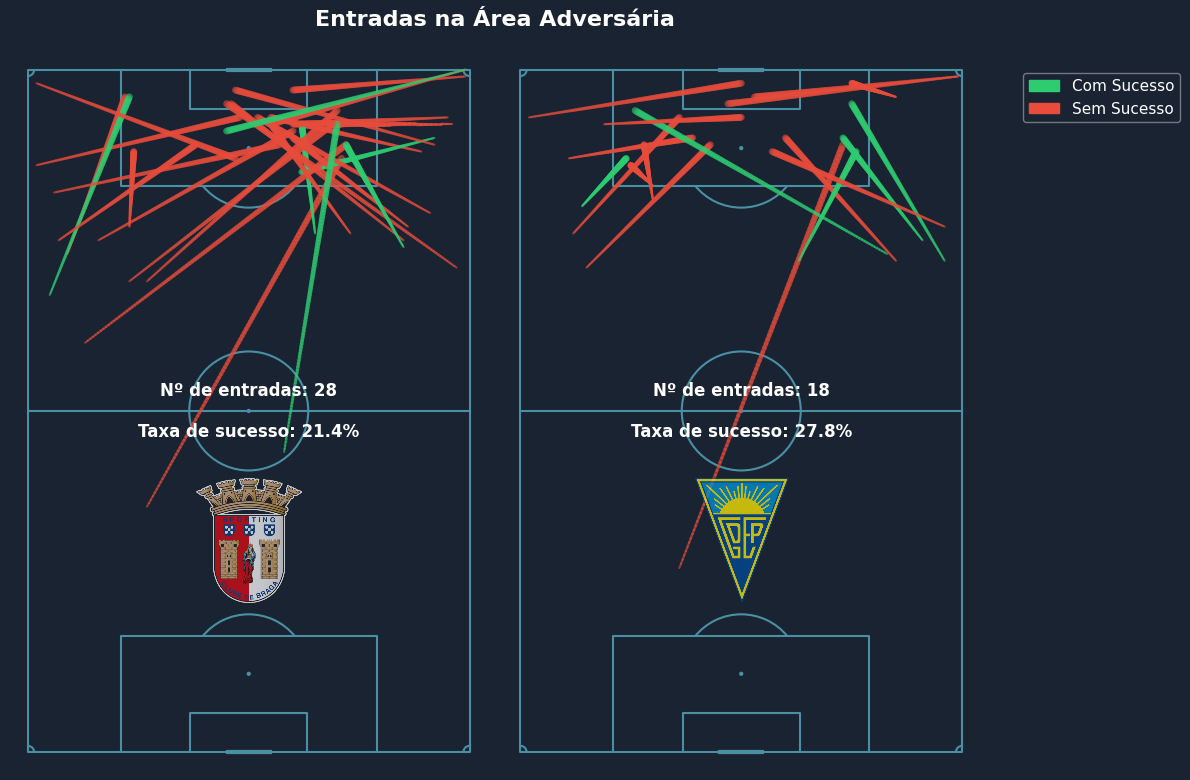

In [8]:
teams = df_entradas_na_area["Team_Name"].unique()

pitch = VerticalPitch(pitch_type = "opta", pitch_color = "#1a2332", line_color = "#4a90a4", linewidth = 1.5, corner_arcs = True)

fig, axes = pitch.draw(ncols = 2, figsize = (10, 8))
fig.patch.set_facecolor("#1a2332")

# Criar gráfico por equipa
for ax, team_name in zip(axes, teams):
    team_df = df_entradas_na_area[df_entradas_na_area["Team_Name"] == team_name].copy()

    # Percorrer os eventos dessa equipa
    for _, row in team_df.iterrows():
        # Ignorar linhas com alguma coordenada em falta
        if pd.isna(row["X_Start"]) or pd.isna(row["X_End"]) or pd.isna(row["Y_Start"]) or pd.isna(row["Y_End"]):
            continue

        # Coordenadas trocadas por ser um VerticalPitch
        x = np.array([row["Y_Start"], row["Y_End"]])
        y = np.array([row["X_Start"], row["X_End"]])

        # Criar segmentos para aumentar a largura da linha (fica com aspeto mais aproximado ao obtido via Tableau)
        n_segments = 100
        t = np.linspace(0, 1, n_segments + 1)
        xi = np.interp(t, [0, 1], x)
        yi = np.interp(t, [0, 1], y)

        color = "#2ecc71" if row["Success"] == "Sim" else "#e74c3c"
        segments = [[[xi[i], yi[i]], [xi[i+1], yi[i+1]]] for i in range(n_segments)]
        linewidths = np.linspace(1.5, 5, n_segments)

        lc = LineCollection(segments, linewidths = linewidths, color = color, alpha = 0.6, capstyle = "round", joinstyle = "round")
        ax.add_collection(lc)

    # Adicionar logo da equipa
    key = [k for k in team_logos if k in team_name][0]
    imagebox = OffsetImage(team_logos[key], zoom = 0.18, alpha = 0.75)
    ab = AnnotationBbox(imagebox, xy = (50, 31), xycoords = "data", frameon = False)
    ax.add_artist(ab)

    # Número total de entradas
    n_entradas = len(team_df)
    ax.text(50, 53, f"Nº de entradas: {n_entradas}", ha = "center", va = "center", color = "white", fontsize = 12, fontweight = "bold")

    # Calcular e adicionar taxa de sucesso
    success_rate = (team_df["Success"] == "Sim").mean()
    success_rate_pct = f"{success_rate * 100:.1f}%"
    ax.text(50, 47, f"Taxa de sucesso: {success_rate_pct}", ha = "center", va = "center", color = "white", fontsize = 12, fontweight = "bold")

# Legenda
success_patch = mpatches.Patch(color = "#2ecc71", label = "Com Sucesso")
fail_patch = mpatches.Patch(color = "#e74c3c", label = "Sem Sucesso")
fig.legend(
    handles = [success_patch, fail_patch],
    loc = "center left",
    ncol = 1,
    facecolor = "#1a2332",
    labelcolor = "white",
    fontsize = 11,
    framealpha = 0.5,
    bbox_to_anchor = (1.02, 0.87)
)

fig.suptitle("Entradas na Área Adversária", color = "white", fontsize = 16, fontweight = "bold")
plt.tight_layout()
plt.show()

Aqui, é rapidamente notória a elevada percentagem de insucessos nas tentativas de entrada na área do SC Braga, especialmente quando comparado com a visualização do lado do GD Estoril-Praia (que teve aproximadamente 1/3 mais eficácia). Em ambos os casos, porém, há uma maior taxa de acerto em tentativas que começam do lado direito de quem ataca, junto à entrada da grande área.

Podemos também analisar de onde partem, tendencialmente, as tentativas de entrada na área das duas equipas. Para isso, vamos aproveitar a ideia de um dos exemplos da [documentação do package mplsoccer](https://mplsoccer.readthedocs.io/en/latest/gallery/pitch_plots/plot_jointgrid.html#sphx-glr-gallery-pitch-plots-plot-jointgrid-py).

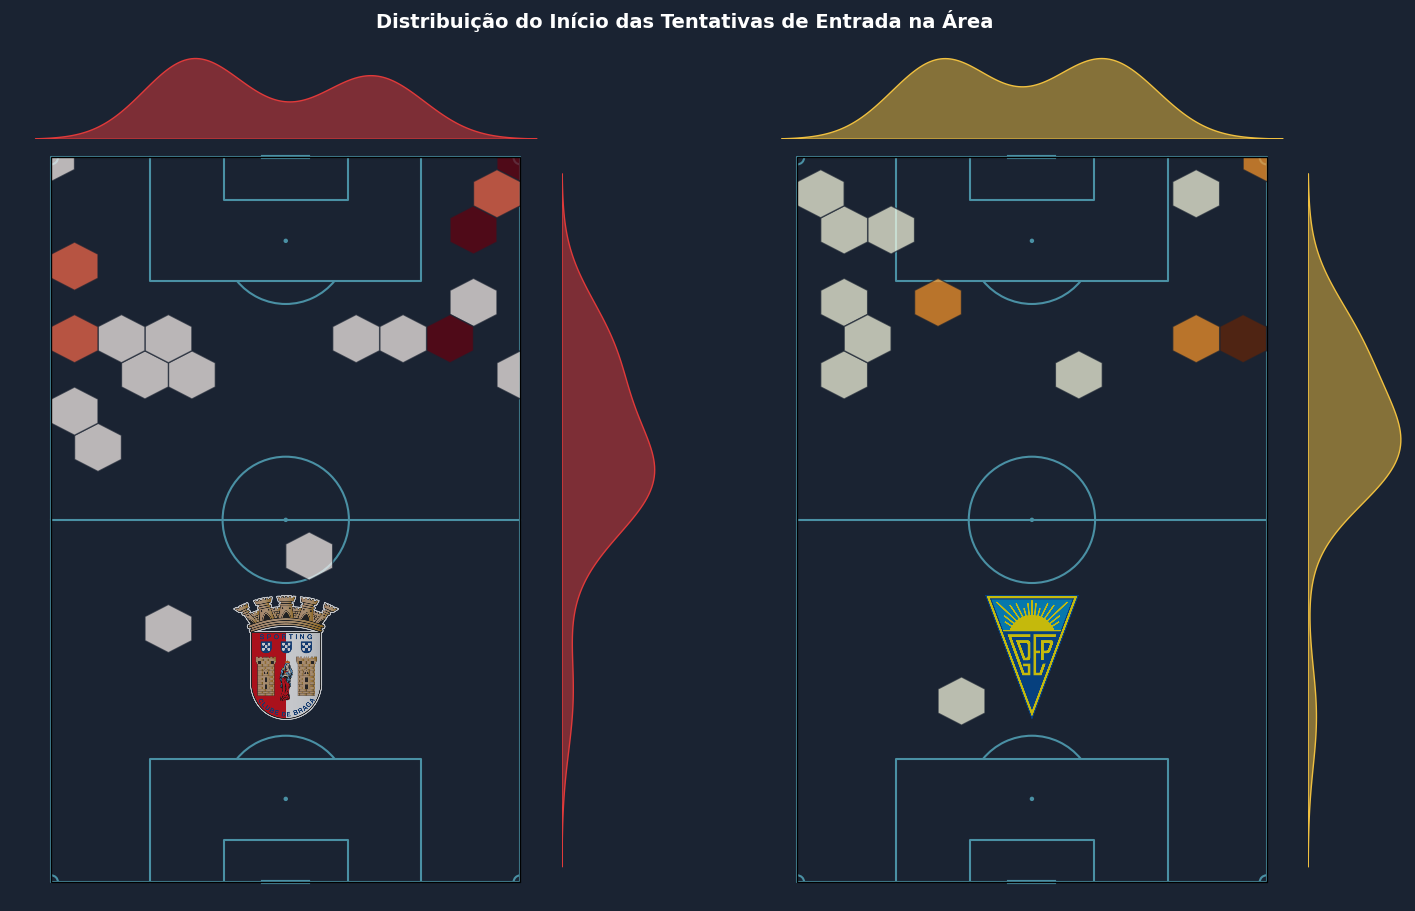

In [9]:
fig = plt.figure(figsize = (18, 11))
fig.patch.set_facecolor("#1a2332")

# 2 colunas (1 por equipa)
outer_gs = gridspec.GridSpec(1, 2, figure = fig, wspace = 0.15)

for col_idx, team_name in enumerate(teams):
    key = [k for k in team_colors if k in team_name][0]
    color = team_colors[key]
    team_df = df_entradas_na_area[df_entradas_na_area["Team_Name"] == team_name].dropna(subset = ["X_Start", "Y_Start"])

    # Criar grelha (2x2)
    inner_gs = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec = outer_gs[col_idx], width_ratios = [0.85, 0.15], height_ratios = [0.1, 0.9], wspace = 0, hspace = 0)

    ax_top = fig.add_subplot(inner_gs[0, 0])
    ax_right = fig.add_subplot(inner_gs[1, 1])
    ax_pitch = fig.add_subplot(inner_gs[1, 0])

    # Desenhar campo
    pitch = VerticalPitch(pitch_type = "opta", pitch_color = "#1a2332", line_color = "#4a90a4", linewidth = 1.5, corner_arcs = True)
    pitch.draw(ax = ax_pitch)

    # Desenhar hexbin
    hb = pitch.hexbin(team_df["X_Start"], team_df["Y_Start"], ax = ax_pitch, gridsize = (10, 10), edgecolors = "#1a2332", cmap = team_cmaps[key], alpha = 0.7)

    # Desenhar e customizar KDEs
    sns.kdeplot(x = team_df["Y_Start"], ax = ax_top, color = color, fill = True, alpha = 0.5)
    sns.kdeplot(y = team_df["X_Start"], ax = ax_right, color = color, fill = True, alpha = 0.5)

    for marginal_ax in [ax_top, ax_right]:
        marginal_ax.set_facecolor("#1a2332")
        for spine in marginal_ax.spines.values():
            spine.set_visible(False)
        marginal_ax.tick_params(left = False, bottom = False, labelleft = False, labelbottom = False)
        marginal_ax.set_xlabel("")
        marginal_ax.set_ylabel("")

    # Adicionar logo da equipa
    imagebox = OffsetImage(team_logos[key], zoom = 0.18, alpha = 0.75)
    ab = AnnotationBbox(imagebox, xy = (50, 31), xycoords = "data", frameon = False)
    ax_pitch.add_artist(ab)

fig.suptitle("Distribuição do Início das Tentativas de Entrada na Área", color = "white", fontsize = 14, fontweight = "bold", y = 0.92)
plt.tight_layout()
plt.show()

Este gráfico seria mais interessante de analisar com uma base maior de jogos que permitisse gerar um visual mais rico. Ainda assim, constatamos a maior preferência das duas equipas (e do SC Braga em especial) para iniciar as suas tentativas antes da linha da grande área e em zonas mais laterais do terreno, sendo bastante rara a tentativa de incursões pela zona central do terreno.

Neste seguimento, podemos explorar por onde são feitas as entradas na área. Para isso, temos de começar por definir a interseção de cada tentativa com os limites da grande área.

In [10]:
# Limites da área
BOX_X_MIN = 83
BOX_X_MAX = 100
BOX_Y_MIN = 21.1
BOX_Y_MAX = 78.9

In [11]:
# Função auxiliar para calcular a interseção
def get_coords_entrada_na_area(row):
    """
    Calcula, via interpolação linear, a interseção da tentativa com o limite da grande área.
    """
    x1, y1 = row["X_Start"], row["Y_Start"]
    x2, y2 = row["X_End"], row["Y_End"]

    # Ignorar linhas com alguma coordenada em falta
    if any(pd.isna(v) for v in [x1, y1, x2, y2]):
        return None

    intersections = []

    # Iterar progressivamente pelas 3 linhas de limite da área (desconsiderando a linha de fundo)
    # 1. Interseção com a linha de entrada na área (paralela à linha de fundo)
    if x2 != x1:
        t = (BOX_X_MIN - x1) / (x2 - x1)
        if 0 <= t <= 1:
            y = y1 + t * (y2 - y1)
            if BOX_Y_MIN <= y <= BOX_Y_MAX:
                intersections.append((t, BOX_X_MIN, y))
    # 2. Interseção com a linha lateral da área (do lado direito de quem ataca)
    if y2 != y1:
        t = (BOX_Y_MIN - y1) / (y2 - y1)
        if 0 <= t <= 1:
            x = x1 + t * (x2 - x1)
            if BOX_X_MIN <= x <= BOX_X_MAX:
                intersections.append((t, x, BOX_Y_MIN))
    # 3. Interseção com a linha lateral da área (do lado esquerdo de quem ataca)
    if y2 != y1:
        t = (BOX_Y_MAX - y1) / (y2 - y1)
        if 0 <= t <= 1:
            x = x1 + t * (x2 - x1)
            if BOX_X_MIN <= x <= BOX_X_MAX:
                intersections.append((t, x, BOX_Y_MAX))
    # Não havendo interseção, devolve nada
    if not intersections:
        return None

    # Devolver a primeira interseção encontrada (só é esperado que haja uma)
    t_min, x_entry, y_entry = min(intersections, key = lambda x: x[0])

    return x_entry, y_entry

In [12]:
df_entradas_na_area[["X_Entry", "Y_Entry"]] = (df_entradas_na_area.apply(get_coords_entrada_na_area, axis = 1).apply(lambda x: pd.Series(x) if x else pd.Series([None, None])))

Já tendo as coordenadas do ponto de entrada na área para cada evento, podemos associar cada uma a um corredor.

In [13]:
def get_corredor(y):
    if y < 33.33:
        return "Esquerdo"
    elif y > 66.66:
        return "Direito"
    else:
        return "Centro"

df_entradas_na_area["Corridor"] = df_entradas_na_area["Y_Entry"].apply(get_corredor)

E, finalmente, criar a visualização.

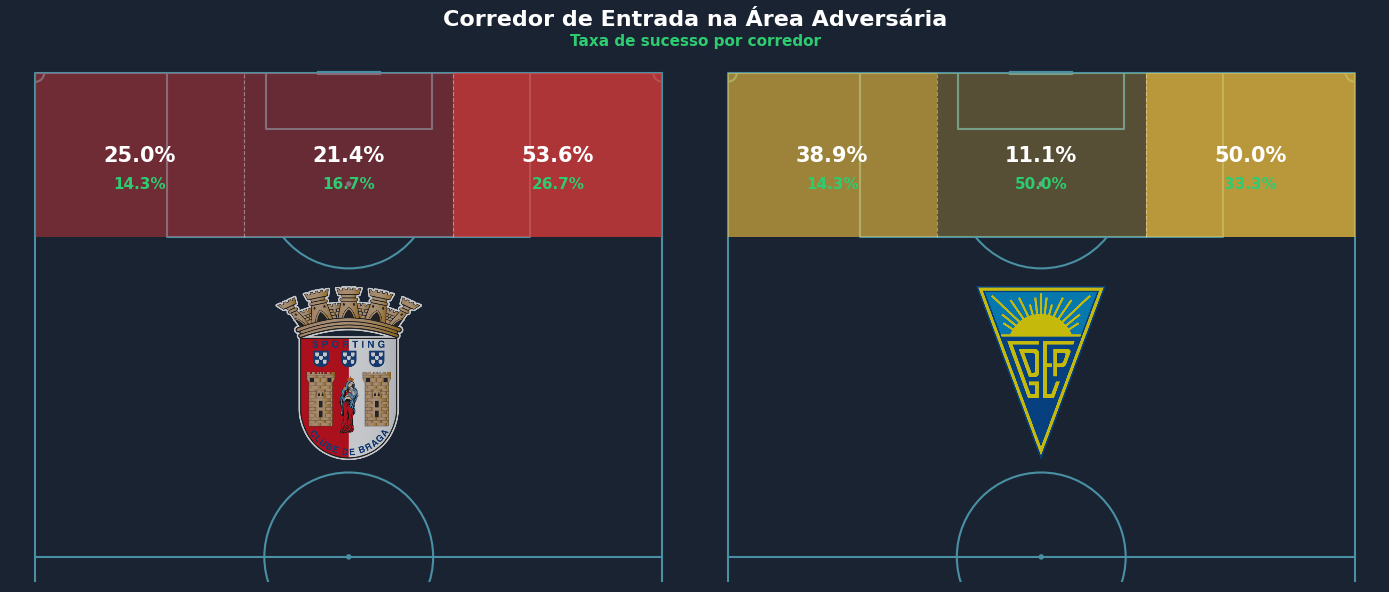

In [14]:
pitch = VerticalPitch(half = True, pitch_type = "opta", pitch_color = "#1a2332", line_color = "#4a90a4", linewidth = 1.5, corner_arcs = True)

fig, axes = pitch.draw(ncols = 2, figsize = (14, 9))
fig.patch.set_facecolor("#1a2332")

for ax, team_name in zip(axes, teams):
    key = [k for k in team_colors if k in team_name][0]
    color = team_colors[key]
    team_df = df_entradas_na_area[df_entradas_na_area["Team_Name"] == team_name].dropna(subset = ["X_Entry", "Y_Entry"])

    # Estatísticas relativas à entrada por corredor
    corridor_counts = team_df["Corridor"].value_counts()
    total = corridor_counts.sum()
    corridor_pct = (corridor_counts / total * 100).round(1)
    max_count = corridor_counts.max()

    corridors = {"Esquerdo": (0, 33.33), "Centro": (33.33, 66.66), "Direito": (66.66, 100)}

    # Percorrer cada corredor
    for corridor, (y_min, y_max) in corridors.items():
        count = corridor_counts.get(corridor, 0)
        pct = corridor_pct.get(corridor, 0)
        alpha = 0.15 + 0.6 * (count / max_count)

        # Desenhar corredor
        rect = plt.Rectangle(
            xy = (y_min, BOX_X_MIN),
            width = y_max - y_min,
            height = BOX_X_MAX - BOX_X_MIN,
            color = color, alpha = alpha, linewidth = 0
        )
        ax.add_patch(rect)

        if y_min > 0:
            ax.plot([y_min, y_min], [BOX_X_MIN, BOX_X_MAX],
                    color = "white", linewidth = 0.8, alpha = 0.4, linestyle = "--")

        # Texto com a percentagem de entradas por esse corredor
        ax.text(
            (y_min + y_max) / 2, (BOX_X_MIN + BOX_X_MAX) / 2,
            f"{pct}%", color = "white", fontsize = 15, fontweight = "bold", ha = "center", va = "center"
        )

        # Texto com a taxa de sucesso dentro das entradas por esse corredor
        corridor_df = team_df[team_df["Corridor"] == corridor]
        success_rate = (corridor_df["Success"] == "Sim").sum() / len(corridor_df) * 100 if len(corridor_df) > 0 else 0
        ax.text(
            (y_min + y_max) / 2, (BOX_X_MIN + BOX_X_MAX) / 2 - 3,
            f"{success_rate:.1f}%", color = "#2ecc71", fontsize = 11, fontweight = "bold", ha = "center", va = "center"
        )

    # Adicionar logo da equipa
    imagebox = OffsetImage(team_logos[key], zoom = 0.25, alpha = 0.75)
    ab = AnnotationBbox(imagebox, xy = (50, 69), xycoords = "data", frameon = False)
    ax.add_artist(ab)

fig.suptitle("Corredor de Entrada na Área Adversária", color = "white", fontsize = 16, fontweight = "bold", y = 0.82)
fig.text(0.5, 0.78, "Taxa de sucesso por corredor", color = "#2ecc71", fontsize = 11, ha = "center", fontweight = "bold")
plt.tight_layout()
plt.show()

Enquanto o SC Braga aparenta ter explorado mais o seu melhor corredor nesta partida, com mais de metade das tentativas a serem feitas pelo lado direito e uma maior taxa de sucesso nesta zona, o Estoril, que também efetuou metade das suas entradas pelo seu corredor direito, apresenta aqui a sua menor taxa de sucesso. <br>
Embora tenha apenas 11.1% de tentativas pela zona central do terreno, evidencia aqui uma taxa de sucesso bastante alta (50%), o que poderia ser justificado pela postura de jogo mais direto, gerando mais espaço interior que o SC Braga teve dificuldades em anular. Esta hipótese é contrariada observando os gráficos anteriores e percebendo que o Estoril só teve 2 tentativas pela zona central e que aquela que foi bem-sucedida começou na verdade no corredor direito, e terminou no esquerdo: simplesmente, no momento de entrada na área, a bola estava na zona central do campo.

Já tendo analisado a distribuição espacial das entradas na área, voltamos agora atenções para a sua variação temporal. Não tendo registado o minuto do jogo em que a tentativa se verificou, vamos usar o tempo de registo do vídeo para gerar uma timeline.

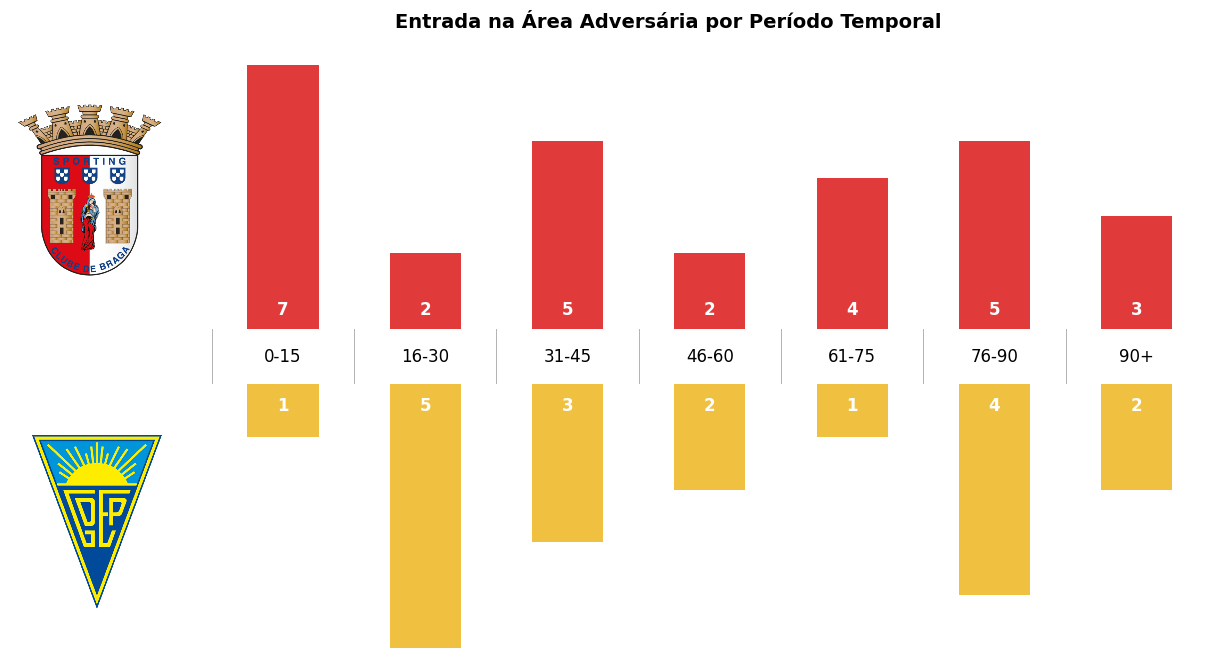

In [15]:
# Criar intervalos de 15 minutos (usando a coluna "Click" como base)
bins = [pd.Timedelta(minutes = m) for m in [0, 15, 30, 45, 60, 75, 90, 150]]
labels = ["0-15", "16-30", "31-45", "46-60", "61-75", "76-90", "90+"]
df_entradas_na_area["Time_Bin"] = pd.cut(df_entradas_na_area["Click"], bins = bins, labels = labels, right = True)

# Estrutura do visual
fig, (ax_home, ax_mid, ax_away) = plt.subplots(3, 1, figsize = (12, 7), gridspec_kw={"height_ratios": [5, 1, 5], "hspace": 0}, facecolor = "white")
fig.patch.set_facecolor("white")

home_team = teams[0]
away_team = teams[1]

for team_name, ax, direction in [(home_team, ax_home, 1), (away_team, ax_away, -1)]:
    key = [k for k in team_colors if k in team_name][0]
    color = team_colors[key]
    team_df = df_entradas_na_area[df_entradas_na_area["Team_Name"] == team_name]
    counts = team_df["Time_Bin"].value_counts().reindex(labels, fill_value = 0)

    # Desenhar barras
    bars = ax.bar(labels, counts, color = color, width = 0.5)

    # Labels dentro das barras
    for bar, count in zip(bars, counts):
        if count > 0:
            x = bar.get_x() + bar.get_width() / 2
            ax.text(x, 0.25, str(count), ha = "center", va = "bottom" if direction == 1 else "top", color = "white", fontsize = 12, fontweight = "bold")

    # Adicionar logo da equipa
    imagebox = OffsetImage(team_logos[key], zoom = 0.25)
    ab = AnnotationBbox(imagebox, (-0.05, 0.5), xycoords = "axes fraction", frameon = False, box_alignment = (1, 0.5))
    ax.add_artist(ab)

    # Customização do gráfico
    ax.set_facecolor("white")
    ax.set_xlim(-0.5, len(labels) - 0.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[["top", "bottom", "left", "right"]].set_visible(False)

    if direction == -1:
        ax.invert_yaxis()

# Customizar parte central
ax_mid.set_facecolor("white")
ax_mid.set_xlim(-0.5, len(labels) - 0.5)
ax_mid.set_ylim(0, 1)
ax_mid.set_xticks([])
ax_mid.set_yticks([])
for spine in ax_mid.spines.values():
    spine.set_visible(False)
# Texto do bin
for i, label in enumerate(labels):
    ax_mid.text(i, 0.5, label, ha = "center", va = "center", color = "black", fontsize = 12)
# Borda a cinzento
for x in [-0.5 + i for i in range(len(labels) + 1)]:
    ax_mid.axvline(x, color = "gray", linewidth = 0.7, alpha = 0.6)

fig.suptitle("Entrada na Área Adversária por Período Temporal", color = "black", fontsize = 14,fontweight = "bold")
plt.subplots_adjust(left = 0.12, right = 0.95, top = 0.92, bottom = 0.05, hspace = 0)
plt.show()

Através deste visual, conseguimos ter uma noção do domínio que cada equipa foi tendo ao longo do jogo. Sabemos, por exemplo, que o Estoril marcou aos 6 minutos, naquela que foi a sua única entrada na área no primeiro quarto de hora do jogo. Depois, no seu período de maior ascendente na partida, foi o SC Braga (que até teve o seu pior registo dos primeiros 45 minutos de vídeo) quem acabou por marcar. Na segunda parte, especialmente no primeiro quarto de hora, o jogo assumiu um ritmo mais calmo e de menor risco, tendo espevitado um pouco como resultado de algumas substituições que foram sendo feitas pelos dois lados. Este visual corrobora os dados de vídeo do jogo, que mostram que de facto foi este o comportamento verificado.
<br><br><br>
Por fim, vamos calcular alguns indicadores na perspetiva ofensiva e defensiva do SC Braga. Neste notebook, não nos iremos focar em criar visualizações com melhor "aspeto", visto que existem visuais próprios em ferramentas como o Power BI e Tableau (que já sugerimos anteriormente como sendo mais apropriadas), ao contrário dos gráficos criados anteriormente.

Começando pela vertente ofensiva, calcularemos o número de jogadores do SC Braga e do adversário na grande área no momento da entrada da bola. Vamos também avaliar a distância média das jogadas (passes ou conduções de bola) que resultam na entrada na área. Para cada uma destas métricas, iremos comparar o valor global com aquele obtido apenas para as tentativas bem sucedidas. Por fim, iremos comparar a taxa de sucesso para os diferentes tipos de jogada observados.

In [16]:
# Criar datasets para o SC Braga (neste caso, a equipa da casa) e para as suas tentativas com sucesso
df_home = df_entradas_na_area[df_entradas_na_area["Team_Name"] == home_team].copy()
df_success = df_home[df_home["Success"] == "Sim"]

In [17]:
metrics = [
    {
        "Métrica": "Jogadores na área em situação ofensiva (SC Braga)",
        "Total": df_home["Attack_Players_In_Area"].mean(),
        "Com Sucesso": df_success["Attack_Players_In_Area"].mean()
    },
    {
        "Métrica": "Jogadores na área em situação ofensiva (adversário)",
        "Total": df_home["Defence_Players_In_Area"].mean(),
        "Com Sucesso": df_success["Defence_Players_In_Area"].mean()
    },
    {
        "Métrica": "Distância média",
        "Total": df_home["Distance"].mean(),
        "Com Sucesso": df_success["Distance"].mean()
    }
]
df_entradas_na_area_metricas_off = pd.DataFrame(metrics)

# Arredondar
df_entradas_na_area_metricas_off[["Total", "Com Sucesso"]] = df_entradas_na_area_metricas_off[["Total", "Com Sucesso"]].round(2)
df_entradas_na_area_metricas_off

,Métrica,Total,Com Sucesso
0,Jogadores na área em situação ofensiva (SC Braga),3.04,2.17
1,Jogadores na área em situação ofensiva (advers...,6.21,4.83
2,Distância média,40.15,34.15


In [18]:
df_taxa_sucesso_tipo_jogada = (
    df_home
    .groupby("Type")["Success"]
    .apply(lambda x: (x == "Sim").mean())
    .reset_index()
    .rename(columns = {"Success": "Taxa de Sucesso"})
)

# Ordenar
df_taxa_sucesso_tipo_jogada = df_taxa_sucesso_tipo_jogada.sort_values(by = "Taxa de Sucesso", ascending = False)
# Converter para percentagem
df_taxa_sucesso_tipo_jogada["Taxa de Sucesso"] = (df_taxa_sucesso_tipo_jogada["Taxa de Sucesso"] * 100).round(2)
df_taxa_sucesso_tipo_jogada

,Type,Taxa de Sucesso
4,Passe Rasteiro (BC),75.00
1,Condução de bola,50.00
0,Canto,33.33
3,Passe Alto (BC),7.14
2,Livre,0.00


A partir dos outputs acima, observamos que, tendencialmente, em cada tentativa de entrada na área do SC Braga havia o dobro de jogadores adversários nesse espaço. Ainda assim, comparando as entradas com sucesso com o valor global, existe sempre um menor número de elementos das duas equipas, o que é algo que até faz sentido: com mais espaço, a probabilidade de chegar dentro da área em situação de bola controlada aumenta. Observamos ainda que a distância média das tentativas é menor para os casos de sucesso, algo também antecipável. <br>
Por último, constatamos que a taxa de sucesso para o SC Braga é bastante superior em situações de passe pelo chão ou em condução de bola por comparação com outros tipos de jogada, como cantos ou passes por alto.

Na perspetiva defensiva, iremos calcular indicadores semelhantes: começamos pelo número de jogadores do SC Braga (agora enquanto equipa que defende) e do adversário na grande área no momento da entrada da bola. Passamos depois para a distância média das jogadas (passes ou conduções de bola) que resultam na entrada na área. Novamente, iremos sempre comparar o valor global com o das tentativas bem sucedidas. Para terminar, vamos comparar a taxa de sucesso (defensivo) para os diferentes tipos de jogada observados.

In [19]:
# Criar dataset para as ações defensivas do SC Braga
df_def = df_entradas_na_area[df_entradas_na_area["Team_Name"] != home_team].copy()
# Lembrando que estamos a atuar na perspetiva do SC Braga, o seu sucesso defensivo corresponde ao não sucesso ofensivo de quem ataca
df_def_success = df_def[df_def["Success"] == "Não"]

In [20]:
metrics_def = [
    {
        "Métrica": "Jogadores na área em situação defensiva (SC Braga)",
        "Total": df_def["Defence_Players_In_Area"].mean(),
        "Com Sucesso": df_def_success["Defence_Players_In_Area"].mean()
    },
    {
        "Métrica": "Jogadores na área em situação defensiva (adversário)",
        "Total": df_def["Attack_Players_In_Area"].mean(),
        "Com Sucesso": df_def_success["Attack_Players_In_Area"].mean()
    }
]
df_entradas_na_area_metricas_def = pd.DataFrame(metrics_def)

# Arredondar
df_entradas_na_area_metricas_def[["Total", "Com Sucesso"]] = df_entradas_na_area_metricas_def[["Total", "Com Sucesso"]].round(2)
df_entradas_na_area_metricas_def

,Métrica,Total,Com Sucesso
0,Jogadores na área em situação defensiva (SC Br...,5.89,6.15
1,Jogadores na área em situação defensiva (adver...,2.56,2.62


In [21]:
df_taxa_sucesso_tipo_jogada_def = (
    df_def
    .groupby("Type")["Success"]
    .apply(lambda x: (x == "Não").mean())
    .reset_index()
    .rename(columns = {"Success": "Taxa de Sucesso"})
)

# Ordenar
df_taxa_sucesso_tipo_jogada_def = df_taxa_sucesso_tipo_jogada_def.sort_values(by = "Taxa de Sucesso", ascending = False)
# Converter para percentagem
df_taxa_sucesso_tipo_jogada_def["Taxa de Sucesso"] = (df_taxa_sucesso_tipo_jogada_def["Taxa de Sucesso"] * 100).round(2)
df_taxa_sucesso_tipo_jogada_def

,Type,Taxa de Sucesso
0,Canto,100.00
3,Passe Rasteiro (BC),83.33
2,Passe Alto (BC),80.00
1,Condução de bola,40.00


Enquanto equipa em situação defensiva, o SC Braga tinha, em média, mais do dobro dos elementos na sua grande área comparativamente com os adversários (que adotaram mais uma estratégia de ataques rápidos e na profundidade). Estes valores não aparentam, neste caso, ter influenciado significativamente as chances de sucesso defensivo da equipa. <br>
Um indicador mais positivo surge ao observar que o SC Braga não concedeu ao adversário nenhuma entrada na sua grande área bem-sucedida a partir de situações de canto, e apresenta também taxas de sucesso bastante interessantes em tentativas de passe em situações de bola corrida, a rondar os 80%. O grande calcanhar de Aquiles foram mesmo as conduções de bola, em que a própria análise de vídeo evidencia alguma passividade e permissividade dos jogadores do SC Braga, que muitas vezes permitiram aos jogadores do Estoril avançar no terreno sem uma contenção mais forte e sem tentar atuar no sentido de recuperar a bola.
<br><br><br>
Estes indicadores serão, naturalmente, valorizados com um conjunto de dados mais alargado e não restrito a apenas um jogo, de modo a permitir analisar e avaliar o comportamento do SC Braga e como os seus adversários procuram enfrentar a equipa. Mesmo assim, estas visualizações e métricas são desde já uma boa base e exemplo do potencial da informação extraída através da codificação manual das partidas, permitindo retirar, a partir de uma métrica tão "simples" como as entradas na área adversária, informação relevante e que nos permite ter uma ideia de como decorreu o jogo como um todo.